# Feature Engineering

## Purpose

Build the **model-ready training dataset** by merging M5 sales data with all external features from notebooks 01a–01e. Starting from 30,490 item-store pairs in wide format, we subsample, reshape to long format, merge pricing and external features, engineer lag/rolling/price features, and **aggregate to the category × store level** (30 groups).

### Output
- `data/output/features.csv` — training set (30 category-store groups, ~26 features)
- `data/output/features_holdout.csv` — last 56 days held out for evaluation

### Pipeline
1. Stratified subsample (300 item-store pairs)
2. Melt wide → long (~574K rows)
3. Merge calendar and weekly prices
4. Engineer price features (lags, change %, relative price)
5. Merge external features (SNAP, events, weather, macro, school)
6. Engineer calendar features
7. **Aggregate to category × store level** (30 groups)
8. Engineer lag/rolling features on aggregated sales
9. Train/holdout split → save

In [1]:
# ── Uncomment below when running on Google Colab ────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/Colab Notebooks/m5-forecasting-accuracy/notebooks')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = ".."
RAW_DIR = f"{BASE_DIR}/data/raw/"
CLEAN_DIR = f"{BASE_DIR}/data/clean/"
OUTPUT_DIR = f"{BASE_DIR}/data/output/"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

---
## 1. Load Data

### Raw M5 Files

In [3]:
#---RAW M5 File---
calendar = pd.read_csv(RAW_DIR + "calendar.csv", parse_dates=["date"])
sell_prices = pd.read_csv(RAW_DIR + "sell_prices.csv")
sales = pd.read_csv(RAW_DIR + "sales_train_validation.csv")

print("calendar:", calendar.shape)
print("sell_prices:", sell_prices.shape)
print("sales:", sales.shape)

calendar: (1969, 14)
sell_prices: (6841121, 4)
sales: (30490, 1919)


### External Feature Files (from notebooks 01a–01e)

In [4]:
snap_features = pd.read_csv(CLEAN_DIR + "snap_features.csv", parse_dates=["date"])
event_features = pd.read_csv(CLEAN_DIR + "event_features.csv", parse_dates=["date"])
weather_daily = pd.read_csv(CLEAN_DIR + "weather_daily.csv", parse_dates=["date"])
macro_indicators = pd.read_csv(CLEAN_DIR + "macro_indicators.csv", parse_dates=["date"])
school_calendar = pd.read_csv(CLEAN_DIR + "school_calendar.csv", parse_dates=["date"])

print("snap_features:", snap_features.shape)
print("event_features:", event_features.shape)
print("weather_daily:", weather_daily.shape)
print("macro_indicators:", macro_indicators.shape)
print("school_calendar:", school_calendar.shape)

snap_features: (5907, 4)
event_features: (1969, 6)
weather_daily: (19690, 13)
macro_indicators: (5907, 9)
school_calendar: (5907, 11)


---
## 2. Stratified Subsample

The full M5 sales data contains **30,490 item-store pairs × 1,913 days ≈ 58 million rows** in long format — exceeding available memory during feature merges. We subsample 10 items per (store, category) stratum: 10 stores × 3 categories = 30 strata × 10 items = **300 item-store pairs → ~574K rows**.

This preserves the full date range (2011–2016), all 10 stores, all 3 categories, and all external feature structure. The tradeoff is reduced item-level generalizability, but at the category-store aggregation level used in modeling, 10 items per group is sufficient.

In [5]:
DATE_START = "2011-01-29"
DATE_END = "2016-06-19"
N_SAMPLE = 10       # items per (store, category) stratum
HOLDOUT_DAYS = 56   # 8 weeks held out for evaluation
SEED = 42

print(f"Sampling: {N_SAMPLE} items per stratum")
print(f"Holdout: last {HOLDOUT_DAYS} days")

Sampling: 10 items per stratum
Holdout: last 56 days


In [6]:
sample_frame = sales[["id", "item_id", "cat_id", "store_id", "state_id"]].copy()

sampled = (
    sample_frame
    .groupby(["store_id", "cat_id"], group_keys=False)
    .apply(lambda g: g.sample(n=min(N_SAMPLE, len(g)), random_state=SEED))
    .reset_index(drop=True)
)

sampled_ids = sampled["id"].tolist()
sales = sales[sales["id"].isin(sampled_ids)].copy()

print("Sampled sales shape:", sales.shape)
print("Unique sampled ids:", sales["id"].nunique())
print("Stores represented:", sales["store_id"].nunique())
print("Categories represented:", sales["cat_id"].nunique())

Sampled sales shape: (300, 1919)
Unique sampled ids: 300
Stores represented: 10
Categories represented: 3


/var/folders/vb/4pmb5txn3rb7v1fcdkh9n63m0000gn/T/ipykernel_78661/1102306751.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(N_SAMPLE, len(g)), random_state=SEED))


---
## 3. Melt Wide → Long

Reshape from wide (one column per day) to long (one row per item-store-day). The `d` column maps to `calendar.csv` for actual dates.

In [7]:
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")]

sales_long = sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)

print("sales_long:", sales_long.shape)
sales_long.head(10)

sales_long: (573900, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_230_CA_1_validation,HOBBIES_1_230,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_242_CA_1_validation,HOBBIES_1_242,HOBBIES_1,HOBBIES,CA_1,CA,d_1,7
2,HOBBIES_1_255_CA_1_validation,HOBBIES_1_255,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_327_CA_1_validation,HOBBIES_1_327,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_399_CA_1_validation,HOBBIES_1_399,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
5,HOBBIES_2_071_CA_1_validation,HOBBIES_2_071,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0
6,HOBBIES_2_081_CA_1_validation,HOBBIES_2_081,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0
7,HOBBIES_2_108_CA_1_validation,HOBBIES_2_108,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0
8,HOBBIES_2_109_CA_1_validation,HOBBIES_2_109,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0
9,HOBBIES_2_123_CA_1_validation,HOBBIES_2_123,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0


---
## 4. Merge Calendar and Prices

Calendar adds actual dates and the Walmart week code (`wm_yr_wk`) needed for price merges. Prices are weekly — after merging, every day in the same week gets the same price. Missing prices (items not yet stocked) are forward-filled within each item’s time series.

In [8]:
calendar_keep = calendar[["d", "date", "wm_yr_wk"]].copy()

features = sales_long.merge(
    calendar_keep,
    on="d",
    how="left"
)

print("After calendar merge:", features.shape)
features.head()

After calendar merge: (573900, 10)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk
0,HOBBIES_1_230_CA_1_validation,HOBBIES_1_230,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
1,HOBBIES_1_242_CA_1_validation,HOBBIES_1_242,HOBBIES_1,HOBBIES,CA_1,CA,d_1,7,2011-01-29,11101
2,HOBBIES_1_255_CA_1_validation,HOBBIES_1_255,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
3,HOBBIES_1_327_CA_1_validation,HOBBIES_1_327,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
4,HOBBIES_1_399_CA_1_validation,HOBBIES_1_399,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101


In [9]:
sell_prices_keep = sell_prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]].copy()

features["wm_yr_wk"] = features["wm_yr_wk"].astype(int)
sell_prices_keep["wm_yr_wk"] = sell_prices_keep["wm_yr_wk"].astype(int)

features = features.drop(
    columns=[c for c in features.columns if c.startswith("sell_price")],
    errors="ignore"
)

features = features.merge(
    sell_prices_keep,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print("After price merge:", features.shape)

missing_price_pct = features["sell_price"].isna().mean() * 100
print(f"Missing sell_price before fill: {missing_price_pct:.2f}%")

features = features.sort_values(["id", "date"]).reset_index(drop=True)

features["sell_price"] = (
    features.groupby("id")["sell_price"]
    .transform(lambda x: x.ffill().bfill())
)

remaining = features["sell_price"].isna().mean() * 100
print(f"Missing sell_price after fill: {remaining:.2f}%")

features = features.dropna(subset=["sell_price"]).reset_index(drop=True)
print("After dropping unrecoverable:", features.shape)

After price merge: (573900, 11)
Missing sell_price before fill: 21.30%
Missing sell_price after fill: 0.00%


After dropping unrecoverable: (573900, 11)


---
## 5. Price Features

Lagged prices and price change capture whether a promotion just started or ended. `price_relative` (current price / training mean) is computed after the train/holdout split to prevent data leakage.

In [10]:
features = features.sort_values(["id", "date"]).reset_index(drop=True)

features["price_lag_7"] = features.groupby("id")["sell_price"].shift(7)
features["price_lag_28"] = features.groupby("id")["sell_price"].shift(28)

features["price_change_pct"] = (
    (features["sell_price"] - features["price_lag_7"]) / features["price_lag_7"]
)

---
## 6. Merge External Features

Merge keys vary by granularity:
- **National** (date only): events
- **State-level** (state_id + date): SNAP, school calendar, macro indicators
- **Store-level** (store_id + date): weather

### SNAP (state-level)

In [11]:
snap_keep = snap_features[[
    "state_id", "date",
    "snap_issuance_proximity"
]].copy()

features = features.merge(
    snap_keep,
    on=["state_id", "date"],
    how="left"
)

### Events (national)

In [12]:
event_keep = event_features[["date", "event_type", "days_until_event", "event_magnitude"]].copy()

features = features.merge(
    event_keep,
    on="date",
    how="left"
)

### Weather (store-level)

In [13]:
weather_keep = weather_daily[[
    "store_id", "state_id", "date",
    "temp_high_f", "precipitation_in", "is_rainy"
]].copy()

features = features.merge(
    weather_keep,
    on=["store_id", "state_id", "date"],
    how="left"
)

### Macro indicators (state-level)

In [14]:
macro_keep = macro_indicators[[
    "state_id", "date",
    "unemployment_state", "cpi"
]].copy()

features = features.merge(
    macro_keep,
    on=["state_id", "date"],
    how="left"
)

### School calendar (state-level)

In [15]:
school_keep = school_calendar[[
    "state_id", "date",
    "is_school_session", "is_summer_break",
    "back_to_school_proximity", "back_to_school_recency"
]].copy()

features = features.merge(
    school_keep,
    on=["state_id", "date"],
    how="left"
)

---
## 7. Calendar Features

Calendar features capture weekly/monthly/seasonal patterns.

In [16]:
features["day_of_week"] = features["date"].dt.dayofweek
features["month"] = features["date"].dt.month
features["week_of_year"] = features["date"].dt.isocalendar().week.astype(int)
features["is_weekend"] = (features["day_of_week"] >= 5).astype(int)

---
## 7a. Aggregate to Category × Store Level

We aggregate item-level data to **category × store** (30 groups) before computing lag/rolling features. This ensures lags are computed on the aggregated sales series, not summed from item-level lags (which would be incorrect for rolling statistics).

- **Sales**: sum across items in each (cat_id, store_id, date) group
- **Prices**: mean across items (represents average category price at each store)
- **External features**: kept as-is (already at date/state/store granularity)

In [17]:
group_keys = ["cat_id", "store_id", "state_id", "date"]

# Sales: sum | Prices: mean | External features: first (identical within group)
agg = features.groupby(group_keys).agg(
    sales=("sales", "sum"),
    sell_price=("sell_price", "mean"),
    price_change_pct=("price_change_pct", "mean"),
    price_lag_7=("price_lag_7", "mean"),
    price_lag_28=("price_lag_28", "mean"),
).reset_index()

external_cols = [
    "snap_issuance_proximity",
    "day_of_week", "month", "week_of_year", "is_weekend",
    "event_type", "days_until_event", "event_magnitude",
    "temp_high_f", "precipitation_in", "is_rainy",
    "unemployment_state", "cpi",
    "is_school_session", "is_summer_break",
    "back_to_school_proximity", "back_to_school_recency",
]
ext = features.groupby(group_keys)[external_cols].first().reset_index()
agg = agg.merge(ext, on=group_keys)

# Create group ID
agg["id"] = agg["cat_id"] + "_" + agg["store_id"]

features = agg.sort_values(["id", "date"]).reset_index(drop=True)

print(f"After aggregation: {features.shape}")
print(f"Groups: {features['id'].nunique()} category-store pairs")
print(f"Mean daily sales: {features['sales'].mean():.1f}")
print(f"% zeros: {(features['sales'] == 0).mean()*100:.1f}%")

After aggregation: (57390, 27)
Groups: 30 category-store pairs
Mean daily sales: 11.2
% zeros: 5.2%


### Interpretation: why aggregate, and why category × store specifically

Item-level forecasting on M5 fights an inherent obstacle: roughly **68% of item-store-day cells are zero-sales**. At that level of sparsity, lag and rolling features carry mostly noise — the 7-day rolling mean of a slow-moving HOBBIES item is dominated by the same-zero pattern repeated, and the model learns calendar artifacts rather than demand signal.

Aggregating to **category × store (30 groups)** trades item-level resolution for statistical power in three ways:

1. **Signal-to-noise**: pooling 100+ items per category-store smooths out item-level idiosyncrasies (return, replenishment, recall events) and surfaces the underlying demand curve. Daily zero-rate at the aggregate level is near zero.
2. **Operational alignment**: Walmart's replenishment decisions are typically made at department/category level by store, not per SKU. The aggregation grain matches the decision grain — a forecast at the level the inventory decision is made.
3. **Computational tractability**: 30 groups × ~2,000 days fits comfortably in memory and trains in seconds, enabling quantile regression in NB04 (5 folds × 3 categories × 4 cost ratios = 60 model fits) that would be intractable at item level.

The trade-off is that we lose the ability to forecast *which* item within a category will sell. For the inventory planning question this project asks (how much stock to order at category-store level), that resolution is not needed.

---
## 8. Lag and Rolling Features

Lag and rolling features capture recent demand history — the strongest predictors in time-series forecasting. All rolling features use `shift(1)` to prevent target leakage. These are computed on **aggregated** category-store sales.

In [18]:
features = features.sort_values(["id", "date"]).reset_index(drop=True)

features["sales_lag_7"] = features.groupby("id")["sales"].shift(7)
features["sales_lag_14"] = features.groupby("id")["sales"].shift(14)
features["sales_lag_28"] = features.groupby("id")["sales"].shift(28)

shifted = features.groupby("id")["sales"].shift(1)
features["rolling_mean_7"] = shifted.rolling(7, min_periods=1).mean().values
features["rolling_mean_28"] = shifted.rolling(28, min_periods=1).mean().values
features["rolling_std_7"] = shifted.rolling(7, min_periods=1).std().values
features["rolling_max_7"] = shifted.rolling(7, min_periods=1).max().values

print("Lag/rolling features computed on aggregated sales")
print(f"Shape: {features.shape}")

Lag/rolling features computed on aggregated sales
Shape: (57390, 34)


---
## 9. Final Column Selection

Keep only the modeling features plus identifiers. Intermediate columns (d, wm_yr_wk, dept_id, item_id) were dropped during aggregation.

In [19]:
final_cols = [
    "id",
    "date",
    "sales",

    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_max_7",

    "sell_price",
    "price_change_pct",
    "price_lag_7",
    "price_lag_28",

    "snap_issuance_proximity",

    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",

    "event_type",
    "days_until_event",
    "event_magnitude",

    "temp_high_f",
    "precipitation_in",
    "is_rainy",

    "unemployment_state",
    "cpi",

    "is_school_session",
    "is_summer_break",
    "back_to_school_proximity",
    "back_to_school_recency",

    "cat_id",
    "store_id",
    "state_id",
]

features = features[final_cols].copy()

print("Final feature dataset shape:", features.shape)
print(f"Groups: {features['id'].nunique()} category-store pairs")

Final feature dataset shape: (57390, 34)
Groups: 30 category-store pairs


---
## 10. Train/Holdout Split

Holdout: last 56 days (8 weeks). Warmup rows (first 28 days per group with incomplete lag features) are dropped from training. `price_relative` is computed using training-set means only — holdout prices are normalized against the same training means to prevent data leakage.

In [20]:
features = features.sort_values(["id", "date"]).reset_index(drop=True)

max_date = features["date"].max()
cutoff_date = max_date - pd.Timedelta(days=HOLDOUT_DAYS - 1)

print("Max date:", max_date)
print("Cutoff date:", cutoff_date)

features_train = features[features["date"] < cutoff_date].copy()
features_holdout = features[features["date"] >= cutoff_date].copy()

warmup_mask = features_train["sales_lag_28"].isna()
print(f"Dropping {warmup_mask.sum():,} warmup rows from training")
features_train = features_train[~warmup_mask]

train_price_mean = features_train.groupby("id")["sell_price"].mean()
features_train["price_relative"] = (
    features_train["sell_price"] / features_train["id"].map(train_price_mean)
)
features_holdout["price_relative"] = (
    features_holdout["sell_price"] / features_holdout["id"].map(train_price_mean)
)

print(f"\nTrain shape: {features_train.shape}")
print(f"Holdout shape: {features_holdout.shape}")
print(f"Groups: {features_train['id'].nunique()} category-store pairs")

print(f"\nTrain date range:",
      features_train["date"].min(), "\u2192", features_train["date"].max())
print(f"Holdout date range:",
      features_holdout["date"].min(), "\u2192", features_holdout["date"].max())

Max date: 2016-04-24 00:00:00
Cutoff date: 2016-02-29 00:00:00
Dropping 840 warmup rows from training

Train shape: (54870, 35)
Holdout shape: (1680, 35)
Groups: 30 category-store pairs

Train date range: 2011-02-26 00:00:00 → 2016-02-28 00:00:00
Holdout date range: 2016-02-29 00:00:00 → 2016-04-24 00:00:00


---
## 11. Save Outputs

In [21]:
features_train.to_csv(OUTPUT_DIR + "features.csv", index=False)
features_holdout.to_csv(OUTPUT_DIR + "features_holdout.csv", index=False)

print("Saved:")
print(OUTPUT_DIR + "features.csv")
print(OUTPUT_DIR + "features_holdout.csv")

Saved:
../data/output/features.csv
../data/output/features_holdout.csv


---
## 12. Verification

In [22]:
features_train.head()

,id,date,sales,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,rolling_max_7,...,unemployment_state,cpi,is_school_session,is_summer_break,back_to_school_proximity,back_to_school_recency,cat_id,store_id,state_id,price_relative
28,FOODS_CA_1,2011-02-26,9,27.0,19.0,19.0,15.714286,16.214286,5.794086,27.0,...,12.0,221.898,1,0,0.0,0.0,FOODS,CA_1,CA,0.987918
29,FOODS_CA_1,2011-02-27,20,19.0,14.0,21.0,13.142857,15.857143,3.484660,19.0,...,12.0,221.898,1,0,0.0,0.0,FOODS,CA_1,CA,0.987918
30,FOODS_CA_1,2011-02-28,11,14.0,19.0,16.0,13.285714,15.821429,3.773340,20.0,...,12.0,221.898,1,0,0.0,0.0,FOODS,CA_1,CA,0.987918
31,FOODS_CA_1,2011-03-01,12,9.0,7.0,18.0,12.857143,15.642857,3.848314,20.0,...,11.9,223.046,1,0,0.0,0.0,FOODS,CA_1,CA,0.987918
32,FOODS_CA_1,2011-03-02,20,13.0,18.0,13.0,13.285714,15.428571,3.498299,20.0,...,11.9,223.046,1,0,0.0,0.0,FOODS,CA_1,CA,0.987918


### Verification Plot

Visual sanity check: average sales and price changes over time at the aggregated category-store level.

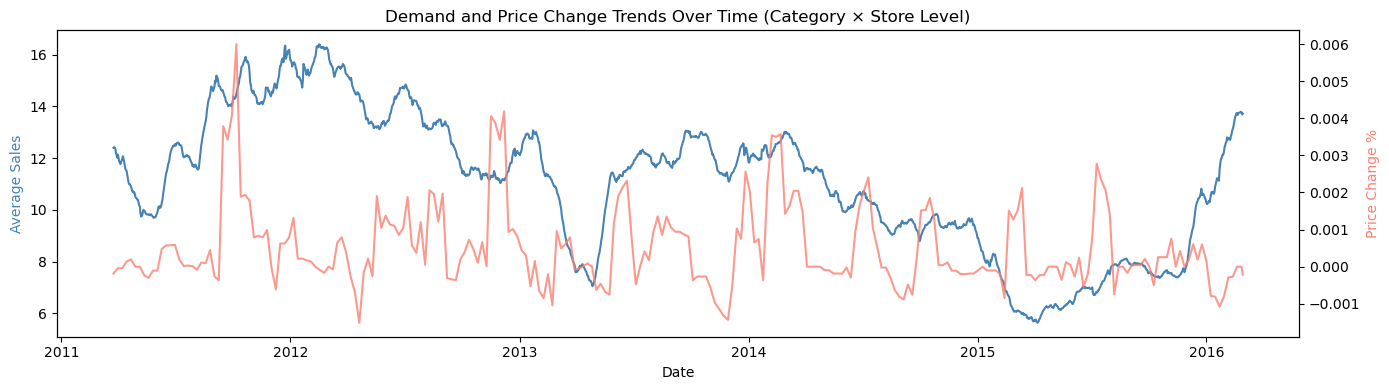

In [23]:
sample_plot = (
    features_train
    .groupby("date")[["sales", "price_change_pct"]]
    .mean()
    .reset_index()
)

# Smooth
sample_plot["sales_smooth"] = sample_plot["sales"].rolling(28).mean()
sample_plot["price_smooth"] = sample_plot["price_change_pct"].rolling(28).mean()

fig, ax1 = plt.subplots(figsize=(14, 4))

# Sales
ax1.plot(sample_plot["date"], sample_plot["sales_smooth"],
         color="steelblue", label="Sales (28-day avg)")
ax1.set_ylabel("Average Sales", color="steelblue")

# Price
ax2 = ax1.twinx()
ax2.plot(sample_plot["date"], sample_plot["price_smooth"],
         color="salmon", alpha=0.8, label="Price Change % (28-day avg)")
ax2.set_ylabel("Price Change %", color="salmon")

ax1.set_title("Demand and Price Change Trends Over Time (Category \u00d7 Store Level)")
ax1.set_xlabel("Date")

plt.tight_layout()
plt.show()

### Interpretation

The verification plots confirm that engineered features behave as expected at the aggregated level: price drops align with visible demand responses, SNAP proximity follows the expected monthly pattern, and rolling averages track short- and medium-term demand trends without leaking current-day information.

---
## Conclusion

This notebook produces the modeling-ready datasets `features.csv` and `features_holdout.csv` at the category-store grain (30 groups × ~1,913 training days + 56 holdout days), with 26 engineered features spanning recent demand history (lags, rolling stats), price dynamics, calendar effects, and external context (SNAP, events, weather, macro indicators, school calendar).

**Key design choices that protect against leakage**:
- All lag and rolling features computed via `groupby('id').shift(...)` on aggregated sales — never on summed item-level lags
- `price_relative` normalized using **training-only** category-store mean prices, applied to both train and holdout
- Warmup rows (first 28 days per group with incomplete rolling features) dropped from training
- Holdout is a strictly forward-time slice (last 56 days), never sampled randomly

**Next**: NB03 trains three models on this dataset (Seasonal Naive, Ridge, XGBoost) and evaluates them under symmetric RMSE. NB04 then introduces asymmetric inventory costs and quantile regression to show that RMSE-optimal forecasts are not cost-optimal forecasts.